In [2]:
#!pip install albumentations
#!pip install selectivesearch
# !pip uninstall opencv-contrib-python opencv-python
#!pip install opencv-contrib-python
#!pip install opencv-contrib-python --upgrade
from IPython.display import clear_output
clear_output(wait=True)

In [3]:
import albumentations as A
import os
import xml.etree.ElementTree as ET
import numpy as np
import cv2
import matplotlib.pyplot as plt
import glob
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import sys
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from PIL import Image, ImageDraw
from tqdm import tqdm
import selectivesearch
import pickle

current_dir = os.getcwd()
print(current_dir)
sys.path.append(current_dir)

/Users/yun/Projects/02516-IDLCV/exe/exe3


In [10]:
data_dir = '../../Potholes/annotated-images'
rate = 0.7

def read_label_content(label_path):
    tree = ET.parse(label_path)
    root = tree.getroot()

    valid_boxes = []
    filename = root.find('filename').text
    for boxes in root.iter('object'):
        ymin = int(boxes.find("bndbox/ymin").text)
        xmin = int(boxes.find("bndbox/xmin").text)
        ymax = int(boxes.find("bndbox/ymax").text)
        xmax = int(boxes.find("bndbox/xmax").text)

        # Check if the bounding box is valid
        # img-415 has a bug in the xml file
        # xmin = xmax.......
        # Potholes/annotated-images/img-415.xml: [xmin=273, ymin=164, xmax=273, ymax=165]
        if xmin >= xmax:
            # Optionally, log the invalid bounding box
            print(f"Invalid bbox in {label_path}: [xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}]")
            # continue  # Skip invalid bounding boxes
            xmin = xmax - 1
        if ymin >= ymax:
            # Optionally, log the invalid bounding box
            print(f"Invalid bbox in {label_path}: [xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}]")
            # continue  # Skip invalid bounding boxes
            ymin = ymax - 1

        valid_boxes.append([xmin, ymin, xmax, ymax])

    return valid_boxes, filename

class PHDataset(torch.utils.data.Dataset):
    def __init__(self, transform, type = 'train'):
        self.image_paths =  sorted(glob.glob(data_dir + '/*.jpg'))
        self.label_paths = sorted(glob.glob(data_dir + '/*.xml'))
        self.transform = transform

        train_idx = int(len(self.image_paths) * rate)
        valid_idx = int(len(self.image_paths) * (rate + (1 - rate) * 0.5))

        if type == 'train':
            self.image_paths = self.image_paths[:train_idx]
            self.label_paths = self.label_paths[:train_idx]
        elif type == 'valid':
            self.image_paths = self.image_paths[train_idx:valid_idx]
            self.label_paths = self.label_paths[train_idx:valid_idx]
        elif type == 'test':
            self.image_paths = self.image_paths[valid_idx:]
            self.label_paths = self.label_paths[valid_idx:]
        else:
            raise ValueError('Invalid type')

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label_path = self.label_paths[idx]
        try:
            image = np.asarray(Image.open(image_path))
            label, filename = read_label_content(label_path)
            class_labels = ['pothole' for _ in range(len(label))]
            transformed = self.transform(image=image, bboxes=label, class_labels=class_labels)
            return transformed['image'], transformed['bboxes'], transformed['class_labels'], filename
        except Exception as e:
            print(f"Error processing image {image_path}: {e}")
            raise ValueError('Error processing image')
        # return 1,2,3

def collate_fn(batch):
    return tuple(zip(*batch))

size = 256
transform = A.Compose([
        A.Resize(size, size),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.RGBShift(r_shift_limit=30, g_shift_limit=30, b_shift_limit=30, p=0.3),
    ],
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']),
)

batch_size = 10
trainset = PHDataset(transform, type='train')
validset = PHDataset(transform, type='valid')
testset = PHDataset(transform, type='test')

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(validset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print(len(trainset), len(validset), len(testset))
print(len(train_loader), len(valid_loader), len(test_loader))


465 100 100
47 10 10


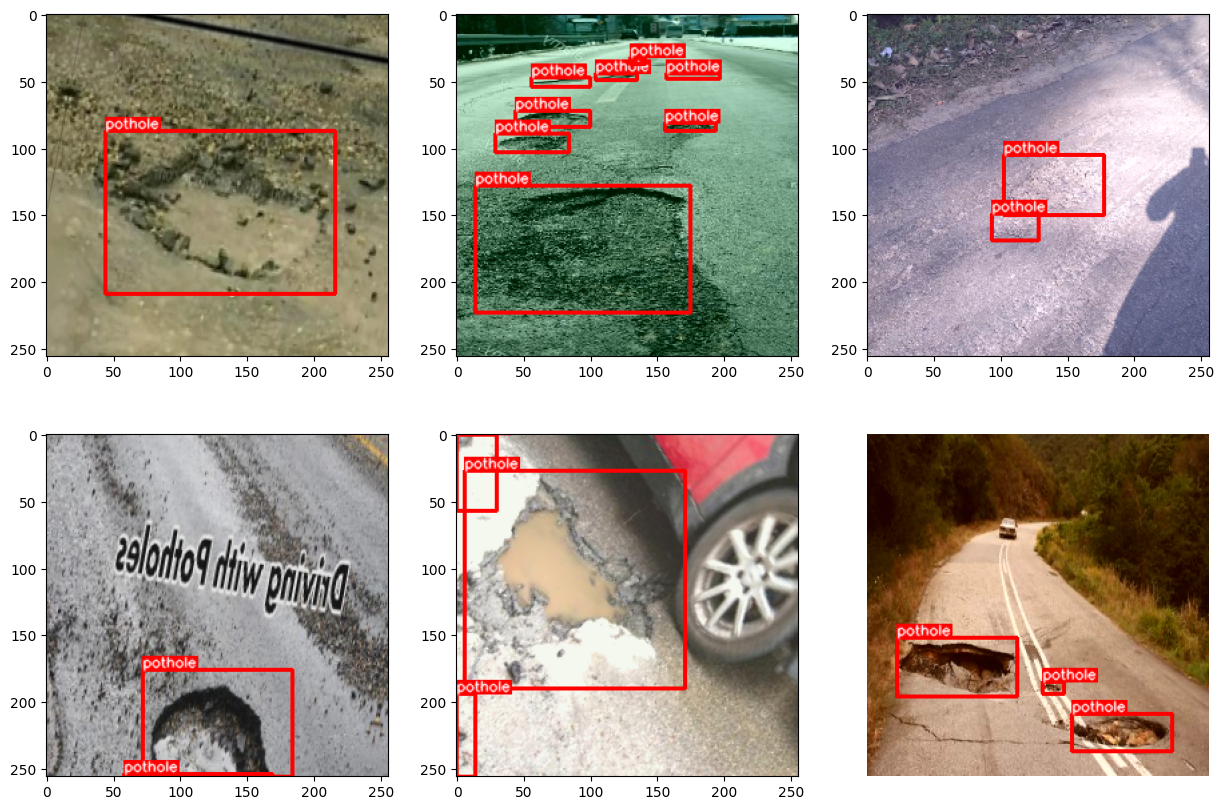

In [26]:
BOX_COLOR = (255, 0, 0) # Red
TEXT_COLOR = (255, 255, 255) # White

def visualize_bbox(img, bbox, class_name, color=BOX_COLOR, thickness=2):
    """Visualizes a single bounding box on the image"""
    x_min, y_min, x_max, y_max = bbox
    x_min, x_max, y_min, y_max = int(x_min), int(x_max), int(y_min), int(y_max)

    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color=color, thickness=thickness)

    ((text_width, text_height), _) = cv2.getTextSize(class_name, cv2.FONT_HERSHEY_SIMPLEX, 0.35, 1)
    cv2.rectangle(img, (x_min, y_min - int(1.3 * text_height)), (x_min + text_width, y_min), BOX_COLOR, -1)
    cv2.putText(
        img,
        text=class_name,
        org=(x_min, y_min - int(0.3 * text_height)),
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=0.35,
        color=TEXT_COLOR,
        lineType=cv2.LINE_AA,
    )
    return img


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

def visualize(image, bboxes, categories, ax):
    img = image.copy()
    for bbox, category in zip(bboxes, categories):
        class_name = category
        img = visualize_bbox(img, bbox, class_name)
    ax.imshow(img)

images, labels, class_labels, filenames = next(iter(valid_loader))

for i in range(6):
    visualize(images[i], labels[i], class_labels[i], axes[i])

plt.axis('off')
plt.show()

In [8]:
class ProposalGenerator:
    def __init__(self):
        pass

    def selective_search_fast(self, image):
        # Convert BGR to RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Compute selective search proposals
        ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
        ss.setBaseImage(image_rgb)
        ss.switchToSelectiveSearchFast()  # Use fast mode

        # Get proposals
        boxes = ss.process()

        # Convert to [x1, y1, x2, y2] format
        proposals = []
        for x, y, w, h in boxes:
            proposals.append([x, y, x+w, y+h])

        return proposals[:1500]

    def edge_boxes(self, image, max_boxes=1500, min_score=0.01):

        # Convert to RGB if necessary
        if len(image.shape) == 3 and image.shape[2] == 3:
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            image_rgb = image

        # Create edge boxes detector
        edge_boxes = cv2.ximgproc.createEdgeBoxes()
        edge_boxes.setMaxBoxes(max_boxes)
        edge_boxes.setMinScore(min_score)

        # Detect edges using Canny
        edges = cv2.Canny(image_rgb, 50, 150)
        edges = edges.astype(np.float32)  # Convert edge map to CV_32F
        orientation_map = np.zeros_like(edges, dtype=np.float32)  # Placeholder orientation map

        # Get bounding boxes
        boxes = edge_boxes.getBoundingBoxes(edges, orientation_map)[0]

        #Convert to [x1, y1, x2, y2] format and scale back
        proposals = []
        for box in boxes:
            x, y, w, h = box
            x = int(x)
            y = int(y)
            w = int(w)
            h = int(h)
            proposals.append([x, y, x+w, y+h])

        return proposals[:3000]

In [33]:
class ProposalEvaluator:
    def __init__(self):
        self.max_proposals = 1500
        self.proposal_steps = np.linspace(0, self.max_proposals, 50, dtype=int)

    def calculate_iou(self, box1, box2):
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])

        intersection = max(0, x2 - x1) * max(0, y2 - y1)
        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

        union = area1 + area2 - intersection
        return intersection / union if union > 0 else 0

    def calculate_recall(self, gt_boxes, proposals, iou_threshold=0.5):
        if not gt_boxes or not proposals:
            return 0

        num_gt = len(gt_boxes)
        detected = np.zeros(num_gt)

        for i, gt_box in enumerate(gt_boxes):
            for prop in proposals:
                if self.calculate_iou(gt_box, prop) >= iou_threshold:
                    detected[i] = 1
                    break

        return detected.mean()

    def calculate_mabo(self, gt_boxes, proposals):
        if not gt_boxes or not proposals:
            return 0

        best_ious = []
        for gt_box in gt_boxes:
            ious = [self.calculate_iou(gt_box, prop) for prop in proposals]
            best_ious.append(max(ious) if ious else 0)

        return np.mean(best_ious)

    def evaluate_proposals(self, dataloader, proposal_func):
        recalls = np.zeros(len(self.proposal_steps))
        mabos = np.zeros(len(self.proposal_steps))
        images_with_this_many_proposals = np.zeros(len(self.proposal_steps))

        count = 0
        for images, labels, _, _ in tqdm(dataloader):
            for idx, image in enumerate(images):
                count += 1
                # Get proposals
                gt_boxes = labels[idx]
                proposals = proposal_func(image)

                # Evaluate for different numbers of proposals
                for i, n_proposals in enumerate(self.proposal_steps):
                    if n_proposals == 0:
                        continue

                    current_proposals = proposals[:n_proposals]

                    recalls[i] += self.calculate_recall(gt_boxes, current_proposals)
                    mabos[i] += self.calculate_mabo(gt_boxes, current_proposals)

                    # Check if all GT Boxes have been detected
                    gt_covered_count = 0
                    for gt_box in gt_boxes:
                        for prop in current_proposals:
                            if self.calculate_iou(gt_box, prop) >= 0.5:
                                gt_covered_count += 1
                                break
                    if gt_covered_count / len(gt_boxes) > 0.5:  # if more than 50% GT Boxes have been detected
                        images_with_this_many_proposals[i] += 1

        # Calculate the average
        recalls /= count
        mabos /= count
        fraction_of_images = images_with_this_many_proposals / count

        return recalls, mabos, fraction_of_images


Evaluating Selective Search Fast...


 62%|██████▏   | 29/47 [03:12<01:45,  5.87s/it]

Invalid bbox in ../../Potholes/annotated-images/img-415.xml: [xmin=273, ymin=164, xmax=273, ymax=165]


100%|██████████| 47/47 [05:00<00:00,  6.40s/it]


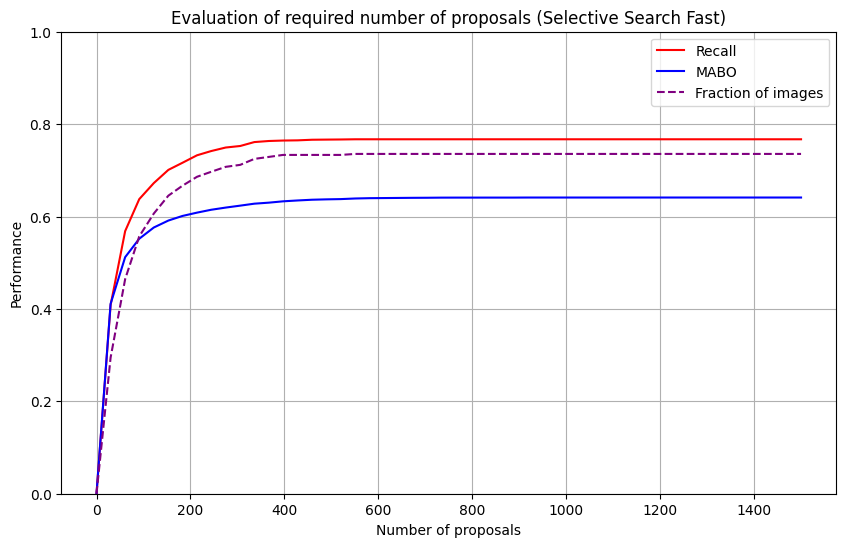


Selective Search Fast optimal number of proposals: 520
- Recall: 0.767
- MABO: 0.638
- Image coverage: 0.733

Evaluating Edge Boxes...


 40%|████      | 19/47 [00:49<01:08,  2.46s/it]

Invalid bbox in ../../Potholes/annotated-images/img-415.xml: [xmin=273, ymin=164, xmax=273, ymax=165]


100%|██████████| 47/47 [01:57<00:00,  2.49s/it]


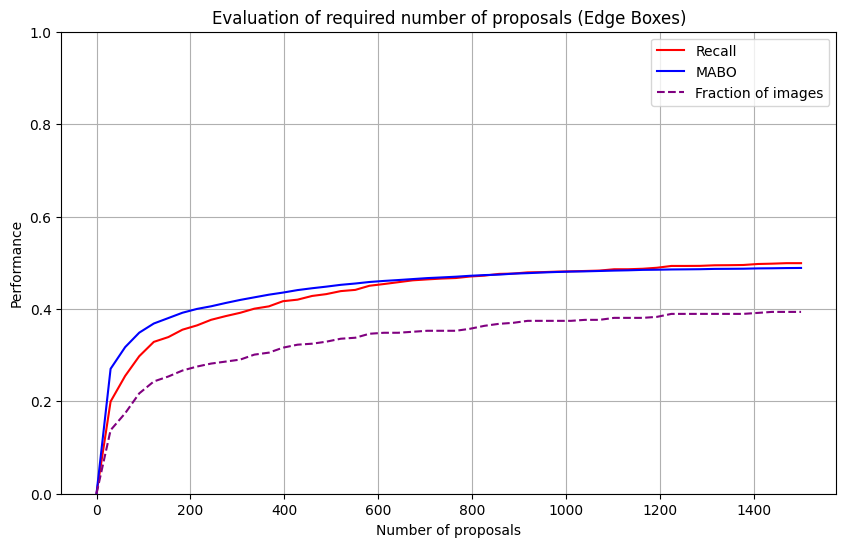


Edge Boxes optimal number of proposals: 673
- Recall: 0.462
- MABO: 0.465
- Image coverage: 0.351


In [34]:
generator = ProposalGenerator()
evaluator = ProposalEvaluator()

print("\nEvaluating Selective Search Fast...")
recalls_ss, mabos_ss, fractions_ss = evaluator.evaluate_proposals(train_loader, generator.selective_search_fast)

# Plot SS results
plt.figure(figsize=(10, 6))
plt.title('Evaluation of required number of proposals (Selective Search Fast)')
plt.grid(True)
plt.plot(evaluator.proposal_steps, recalls_ss, label='Recall', color='red')
plt.plot(evaluator.proposal_steps, mabos_ss, label='MABO', color='blue')
plt.plot(evaluator.proposal_steps, fractions_ss, '--', label='Fraction of images', color='purple')
plt.xlabel('Number of proposals')
plt.ylabel('Performance')
plt.legend()
plt.ylim(0, 1)
plt.show()

# Print SS optimal numbers
min_proposals = 500
max_proposals = 1500

# Only consider proposals that are within a reasonable range
valid_indices = np.where((evaluator.proposal_steps >= min_proposals) &
                        (evaluator.proposal_steps <= max_proposals))[0]
valid_recalls = recalls_ss[valid_indices]
valid_steps = evaluator.proposal_steps[valid_indices]

# Select the optimal point based on the balance between recall and proposal numbers
# Use recall/log(proposals) as a metric to balance recall and proposal numbers
efficiency = valid_recalls / np.log(valid_steps)
optimal_idx = valid_indices[np.argmax(efficiency)]
optimal_proposals = evaluator.proposal_steps[optimal_idx]

print(f"\nSelective Search Fast optimal number of proposals: {optimal_proposals}")
print(f"- Recall: {recalls_ss[optimal_idx]:.3f}")
print(f"- MABO: {mabos_ss[optimal_idx]:.3f}")
print(f"- Image coverage: {fractions_ss[optimal_idx]:.3f}")

# Evaluate Edge Boxes
print("\nEvaluating Edge Boxes...")
recalls_eb, mabos_eb, fractions_eb = evaluator.evaluate_proposals(train_loader, generator.edge_boxes)

# Plot Edge Boxes results
plt.figure(figsize=(10, 6))
plt.title('Evaluation of required number of proposals (Edge Boxes)')
plt.grid(True)
plt.plot(evaluator.proposal_steps, recalls_eb, label='Recall', color='red')
plt.plot(evaluator.proposal_steps, mabos_eb, label='MABO', color='blue')
plt.plot(evaluator.proposal_steps, fractions_eb, '--', label='Fraction of images', color='purple')
plt.xlabel('Number of proposals')
plt.ylabel('Performance')
plt.legend()
plt.ylim(0, 1)
plt.show()

# Print Edge Boxes optimal numbers
valid_recalls = recalls_eb[valid_indices]
efficiency = valid_recalls / np.log(valid_steps)
optimal_idx = valid_indices[np.argmax(efficiency)]
optimal_proposals = evaluator.proposal_steps[optimal_idx]

print(f"\nEdge Boxes optimal number of proposals: {optimal_proposals}")
print(f"- Recall: {recalls_eb[optimal_idx]:.3f}")
print(f"- MABO: {mabos_eb[optimal_idx]:.3f}")
print(f"- Image coverage: {fractions_eb[optimal_idx]:.3f}")

In [75]:
data_dir = '../../Potholes/annotated-images'

class ImageProcessor:
    def __init__(self, image_paths, label_paths, proposal_generator, size = (256, 256)):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.proposal_generator = proposal_generator
        self.size = size


    def generate_proposals(self, image, gt_boxes):
        proposals = self.proposal_generator(image)
        proposals = self.assign_labels(proposals, gt_boxes)

        return proposals

    def resize_gt_boxes(self, gt_boxes, scale):
        x_scale, y_scale = scale
        gt_boxes = [(x1 * x_scale, y1 * y_scale, x2 * x_scale, y2 * y_scale) for x1, y1, x2, y2 in gt_boxes]
        return gt_boxes

    def assign_labels(self, proposals, gt_boxes, positive_iou_threshold=0.5, negative_iou_threshold=0.1):
      new_proposals = []
      for proposal in proposals:
          max_iou = 0.0
          assigned_label = 0  # Background class
          for gt_box in gt_boxes:
              iou = self.calculate_iou(proposal, gt_box)
              if iou > max_iou:
                  max_iou = iou
                  if iou >= positive_iou_threshold:
                      assigned_label = 1  # Object class label (assuming single class)
          if max_iou >= positive_iou_threshold or max_iou <= negative_iou_threshold:
              new_proposals.append([proposal[0], proposal[1], proposal[2], proposal[3], assigned_label])
          else:
              continue
              # Ignored sample
      return new_proposals

    def calculate_iou(self, box1, box2):
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])

        intersection = max(0, x2 - x1) * max(0, y2 - y1)
        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

        union = area1 + area2 - intersection
        return intersection / union if union > 0 else 0

    def read_label_content(self, label_path):
        tree = ET.parse(label_path)
        root = tree.getroot()

        valid_boxes = []
        filename = root.find('filename').text
        for boxes in root.iter('object'):
            ymin = int(boxes.find("bndbox/ymin").text)
            xmin = int(boxes.find("bndbox/xmin").text)
            ymax = int(boxes.find("bndbox/ymax").text)
            xmax = int(boxes.find("bndbox/xmax").text)

            # Check if the bounding box is valid
            # img-415 has a bug in the xml file
            # xmin = xmax.......
            # Potholes/annotated-images/img-415.xml: [xmin=273, ymin=164, xmax=273, ymax=165]
            if xmin >= xmax:
                # Optionally, log the invalid bounding box
                print(f"Invalid bbox in {label_path}: [xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}]")
                # continue  # Skip invalid bounding boxes
                xmin = xmax - 1
            if ymin >= ymax:
                # Optionally, log the invalid bounding box
                print(f"Invalid bbox in {label_path}: [xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}]")
                # continue  # Skip invalid bounding boxes
                ymin = ymax - 1

            valid_boxes.append([xmin, ymin, xmax, ymax])

        return valid_boxes, filename

    def process_image(self, idx):
        image_path = self.image_paths[idx]
        label_path = self.label_paths[idx]

        image = cv2.imread(image_path)
        scale = (self.size[1] / image.shape[1], self.size[0] / image.shape[0])
        image = cv2.resize(image, self.size)
        gt_boxes, filename = self.read_label_content(label_path)
        gt_boxes = self.resize_gt_boxes(gt_boxes, scale)
        proposals = self.generate_proposals(image, gt_boxes)
        print(proposals)
        return {
            'filename': filename,
            'image': image,
            'image_path': image_path,
            'size': self.size,
            'gt_boxes': gt_boxes,
            'proposals': proposals,
        }

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        return self.process_image(idx)

def precompute_proposals_and_labels(image_processor, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    for image_data in tqdm(image_processor):
        filename = image_data['filename']
        with open(os.path.join(output_dir, f'samples_{filename}.pkl'), 'wb') as f:
            pickle.dump(image_data, f)

image_paths =  sorted(glob.glob(data_dir + '/img-1.jpg'))
label_paths = sorted(glob.glob(data_dir + '/img-1.xml'))
processor = ImageProcessor(image_paths, label_paths, ProposalGenerator().selective_search_fast)
precompute_proposals_and_labels(processor, './test_proposals')

100%|██████████| 1/1 [00:00<00:00,  3.97it/s]

[[156, 243, 174, 256, 0], [108, 62, 135, 68, 0], [96, 146, 125, 172, 0], [245, 5, 256, 45, 0], [129, 0, 256, 71, 0], [57, 132, 80, 154, 0], [180, 100, 256, 204, 0], [245, 6, 256, 21, 0], [135, 126, 199, 182, 0], [69, 125, 124, 182, 0], [147, 20, 180, 29, 0], [147, 6, 256, 38, 0], [168, 6, 256, 38, 0], [68, 196, 86, 215, 0], [160, 89, 186, 99, 0], [109, 87, 144, 97, 0], [162, 79, 194, 96, 0], [0, 0, 256, 256, 0], [96, 151, 123, 183, 0], [153, 239, 174, 256, 0], [26, 121, 124, 182, 0], [80, 87, 187, 154, 1], [238, 57, 252, 75, 0], [158, 101, 256, 256, 0], [26, 134, 69, 172, 0], [160, 89, 185, 99, 0], [168, 106, 256, 256, 0], [74, 86, 143, 129, 1], [148, 20, 185, 29, 0], [88, 162, 111, 188, 0], [47, 132, 81, 163, 0], [98, 182, 188, 256, 0], [224, 131, 244, 159, 0], [34, 68, 74, 91, 0], [200, 99, 256, 183, 0], [148, 178, 205, 245, 0], [136, 164, 149, 183, 0], [147, 16, 238, 39, 0], [51, 162, 78, 195, 0], [76, 86, 143, 129, 1], [185, 195, 211, 226, 0], [34, 240, 61, 256, 0], [99, 196, 127, 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


gt_boxes shape: (1, 4)
gt_box: [ 75  85 186 134]


IndexError: index 1 is out of bounds for dimension 0 with size 1

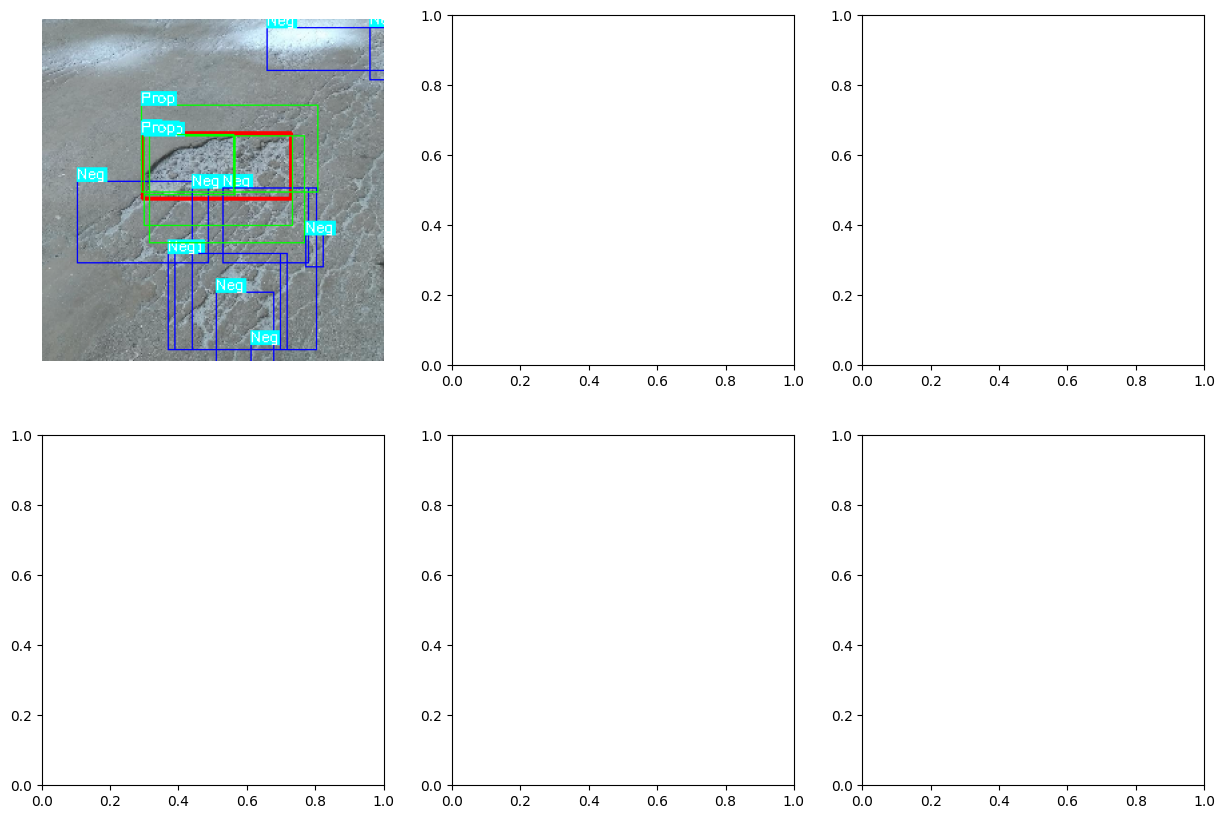

In [128]:
import random

class ProposalDataset(torch.utils.data.Dataset):
    def __init__(self, samples_dir, num_samples = 10, transform=None):
        self.samples = []
        self.transform = transform
        self.num_samples = num_samples
        self.sample_files = sorted(glob.glob(os.path.join(samples_dir, 'samples_*.pkl')))

        for file in self.sample_files:
            sample = pickle.load(open(file, 'rb'))
            image_path = sample['image_path']
            image = sample['image']
            proposals = sample['proposals']
            gt_boxes = sample['gt_boxes']
            positives = [p for p in proposals if p[4] == 1]
            negatives = [p for p in proposals if p[4] == 0]
            sampled_positives = random.sample(positives, min(len(positives), self.num_samples))
            sampled_negatives = random.sample(negatives, min(len(negatives), self.num_samples))
            sampled_proposals = sampled_positives + sampled_negatives
            random.shuffle(sampled_proposals)

            self.samples.append({
                'image': image,
                'image_path': image_path,
                'proposals': sampled_proposals,
                'gt_boxes': gt_boxes,
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = sample['image']
        proposals = torch.tensor(np.array(sample['proposals']), dtype=torch.long)
        gt_boxes = torch.tensor(np.array(sample['gt_boxes']), dtype=torch.long)
        # if self.transform:
        #     image = self.transform(image)
        # else:
        image = transforms.ToTensor()(image)
        # image = image.permute(1, 2, 0)
        return image, gt_boxes, proposals

# transform = transforms.Compose([
#     transforms.ToPILImage(),
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
# ])


dataset = ProposalDataset(samples_dir='./test_proposals')
dataloader = DataLoader(dataset, batch_size=10, shuffle=False)


TEXT_COLOR = (255, 255, 255) # White
GREEN_COLOR = (0, 255, 0) # GREEN
BLUE_COLOR = (0, 0, 255) # BLUE

def visualize_bbox(img, bbox, class_name, color=(255, 0, 0), thickness=2):
    """Visualizes a single bounding box on the image"""
    x_min, y_min, x_max, y_max = bbox
    x_min, x_max, y_min, y_max = int(x_min), int(x_max), int(y_min), int(y_max)

    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color=color, thickness=thickness)

    ((text_width, text_height), _) = cv2.getTextSize(class_name, cv2.FONT_HERSHEY_SIMPLEX, 0.35, 1)
    cv2.rectangle(img, (x_min, y_min - int(1.3 * text_height)), (x_min + text_width, y_min), BOX_COLOR, -1)
    cv2.putText(
        img,
        text=class_name,
        org=(x_min, y_min - int(0.3 * text_height)),
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=0.35,
        color=TEXT_COLOR,
        lineType=cv2.LINE_AA,
    )
    return img

def visualize_proposals(img, ground_truth_boxes, proposals):
    img = img.copy()
    print('gt_boxes shape:', ground_truth_boxes.shape)
    for gt_box in ground_truth_boxes:
        print('gt_box:', gt_box)
        img = visualize_bbox(img, gt_box, 'GT', 2)
    for proposal in proposals:
        box = proposal[:4]
        class_name = 'Prop' if proposal[4] == 1 else 'Neg'
        img = visualize_bbox(img, box, class_name, color=GREEN_COLOR if proposal[4] == 1 else BLUE_COLOR, thickness=1)
    return img

images, gt_boxes, proposals = next(iter(dataloader))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(6):
    img = visualize_proposals(images[i].numpy().transpose(1, 2, 0), gt_boxes[i].numpy(), proposals[i].numpy())
    axes[i].imshow(img)
    axes[i].axis('off')

plt.show()
